In [38]:
import os

import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from joblib import Memory, Parallel, delayed, dump, load
from IPython import display

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, RocCurveDisplay
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import label_binarize
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns


load crop data and standard scale

In [50]:
# data = pd.read_csv('crop_recommendation_dataset.csv')
# features = data[['Temperature', 'Humidity', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']]
data = pd.read_csv('fertilizer_recommendation_dataset.csv')

features = data[['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']]


# 按 crop 分组，计算每个特征的均值
# crop_features = data.groupby('Crop')[features.columns].mean()
crop_features = features
# 按 crop 分组，计算每个特征的均值
crop_features = data.groupby('Crop')[features.columns].mean()

# 数据标准化
scaler = MinMaxScaler()
scaled_crop_features = scaler.fit_transform(crop_features)

# Delete the duplicate rows in the dataset
data.drop_duplicates(inplace=True)
data.shape

(3100, 12)

In [51]:
# Display the number of negtive values in each numeric column
negative_values_per_column = (df.select_dtypes(include=[np.number]) < 0).sum()
# Drop the rows with negative values
data = data[(data.select_dtypes(include=[np.number]) >= 0).all(axis=1)]
print("Shape of the dataset after dropping negative values:", data.shape)
data.describe()

Shape of the dataset after dropping negative values: (2798, 12)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000,2798.000000
mean,27.248445,0.600667,115.754129,6.378720,61.285696,71.995526,71.734111,1.528203
std,9.106030,0.144215,71.671051,0.959385,10.211103,38.809166,32.778179,0.641954
min,4.011486,0.227436,1.322761,3.448974,35.527718,12.445888,29.635327,0.248064
25%,22.362842,0.494399,64.186879,5.856926,54.824953,43.933213,50.453392,1.001590
50%,26.175915,0.599853,98.133146,6.337308,59.425446,58.779200,59.160315,1.485274
75%,30.003216,0.707487,149.433380,6.899573,65.767304,86.970556,76.831866,2.022368
max,56.653592,0.972361,411.955947,9.562341,97.854559,177.314481,161.067982,3.241984


Search for the best k

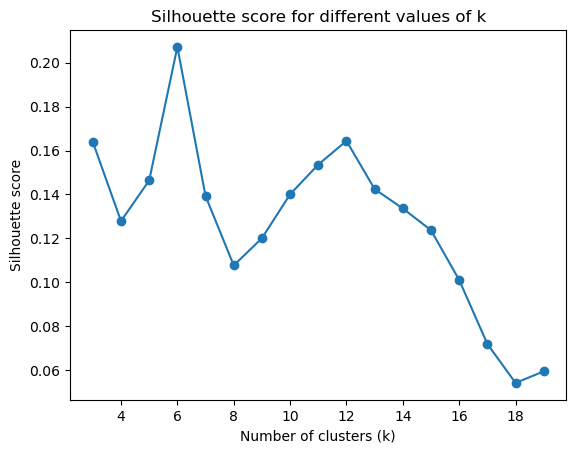

Best number of clusters (based on silhouette score): 6


In [52]:
silhouette_scores = []
k_range = range(3, 20)  # 尝试不同的簇数，从 2 到 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_crop_features)
    score = silhouette_score(scaled_crop_features, labels)
    silhouette_scores.append(score)

# 绘制轮廓系数随簇数变化的曲线
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for different values of k')
plt.show()

# 找到最大轮廓系数对应的簇数
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"Best number of clusters (based on silhouette score): {best_k}")

Cluster the data with k=5, and use PCA to lower the dimension for visualization.

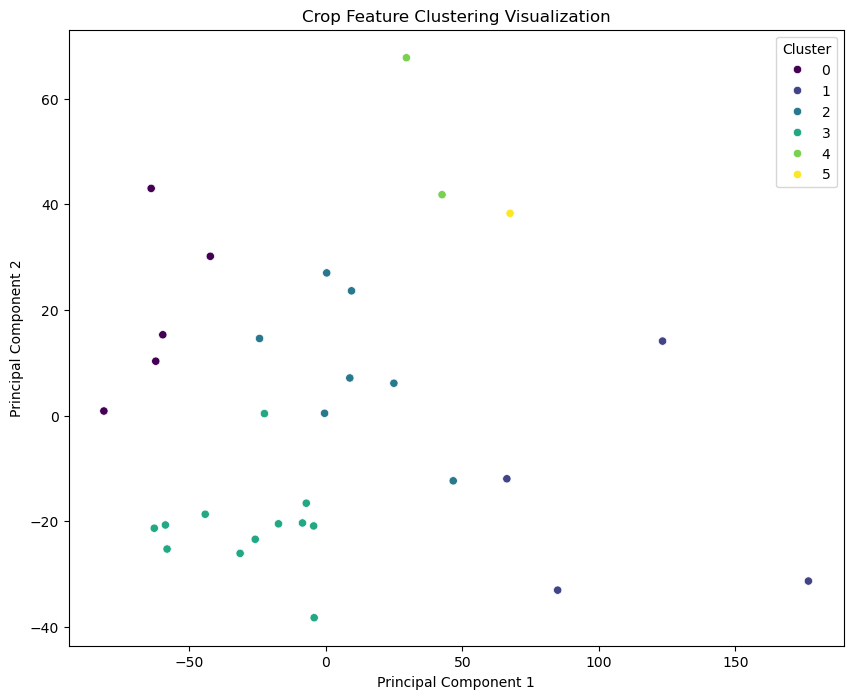

Cluster 0 contains 5 samples.
Cluster 1 contains 4 samples.
Cluster 2 contains 7 samples.
Cluster 3 contains 12 samples.
Cluster 4 contains 2 samples.
Cluster 5 contains 1 samples.


In [53]:
# 假设通过评估确定簇数为 6
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(crop_features)

# 使用 PCA 将数据降到二维以便可视化
pca = PCA(n_components=2)
pca_result = pca.fit_transform(crop_features)

# 创建一个 DataFrame 用于可视化
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Cluster'] = labels

# 可视化
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('Crop Feature Clustering Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# 遍历每个簇，打印样本数量
for cluster in range(k):
    cluster_samples = pca_df[pca_df['Cluster'] == cluster].shape[0]
    print(f"Cluster {cluster} contains {cluster_samples} samples.")

Visualize different cluster attribute with bar chart and radar chart.

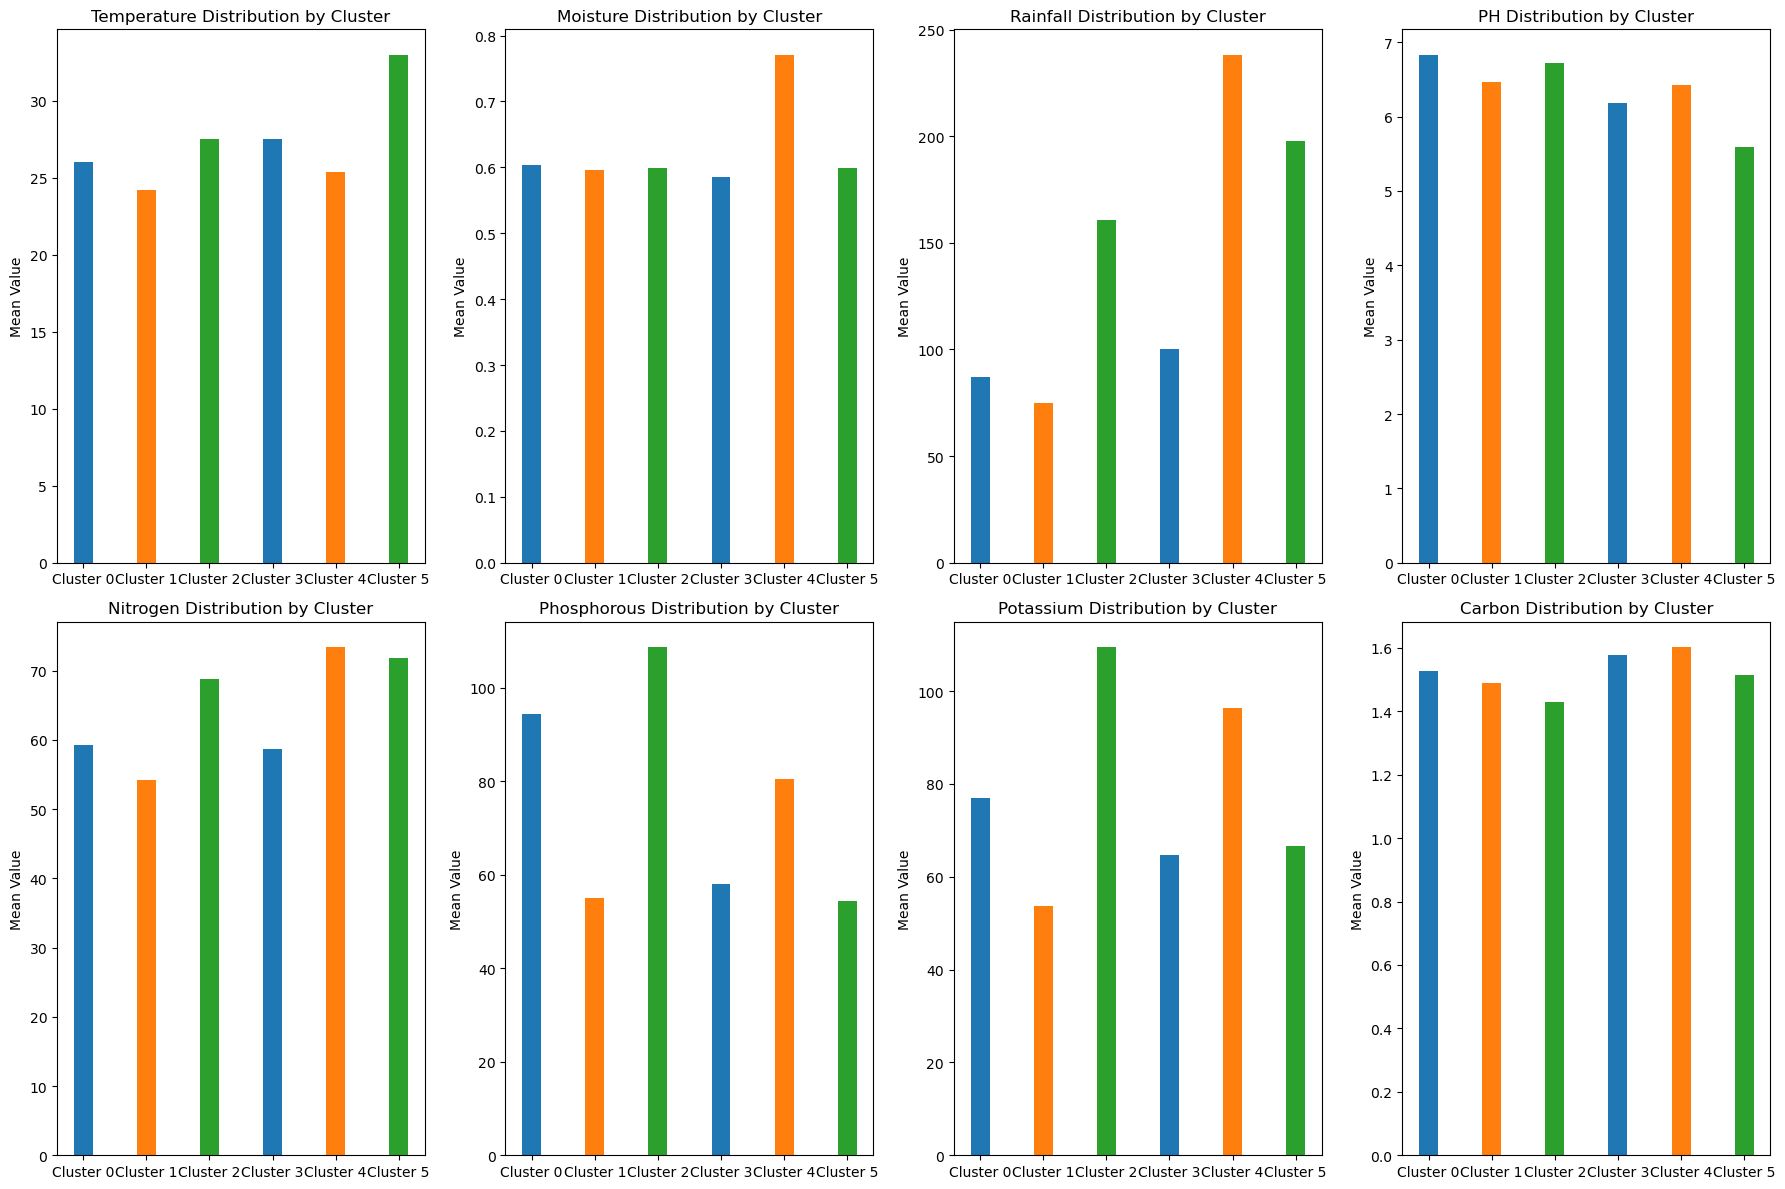

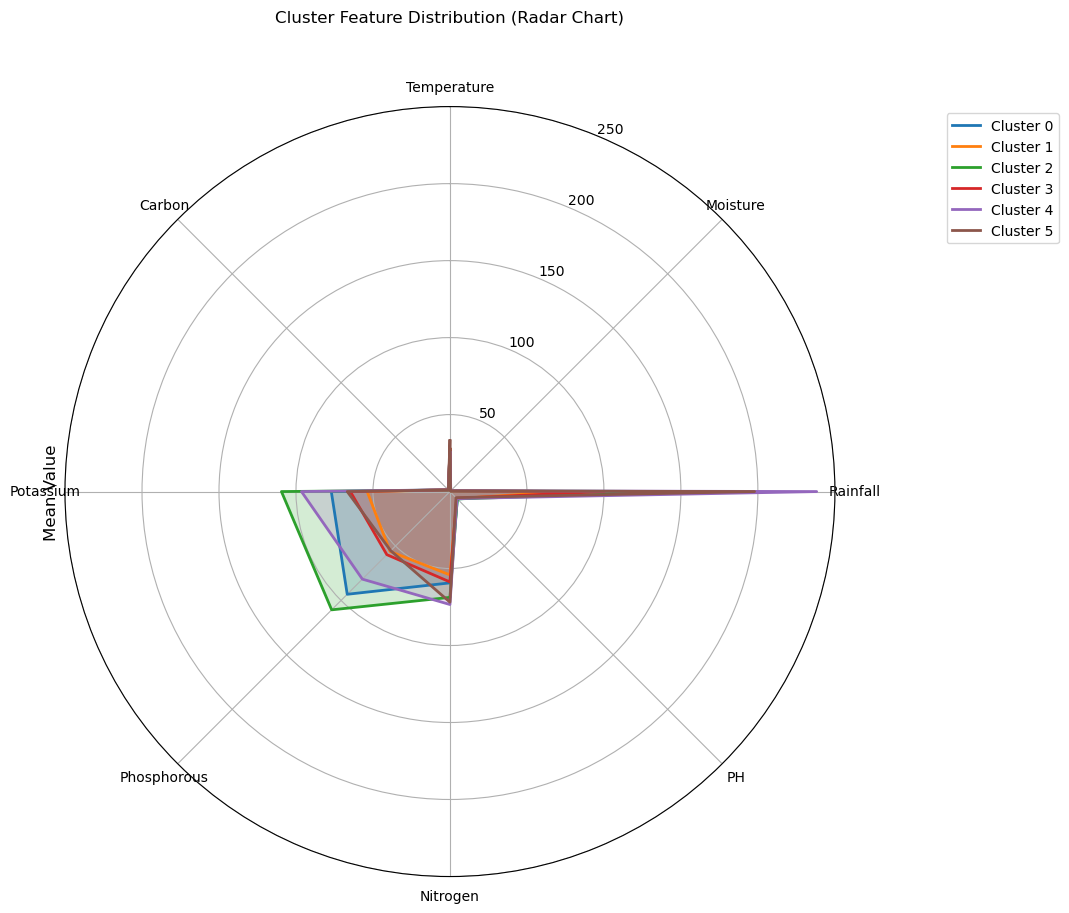

In [54]:
# 假设通过评估确定簇数为 5
k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(scaled_crop_features)

# 创建 crop 到聚类标签的映射
crop_to_cluster = dict(zip(crop_features.index, labels))

# 将聚类标签添加到原始数据中
data['Cluster'] = data['Crop'].map(crop_to_cluster)

# 计算每个簇的特征均值
cluster_means = data.groupby('Cluster')[features.columns].mean().reset_index()

# 绘制分组柱状图
plt.figure(figsize=(18, 12))

for i, feature in enumerate(features.columns):
    plt.subplot(2, 4, i + 1)  # 2行4列子图布局
    clusters = cluster_means['Cluster']
    means = cluster_means[feature]

    bar_width = 0.3
    x = np.arange(len(clusters))  # 簇的位置

    plt.bar(x, means, width=bar_width, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title(f'{feature} Distribution by Cluster')
    plt.xticks(x, [f'Cluster {c}' for c in clusters])
    plt.ylabel('Mean Value')

plt.tight_layout()
plt.show()


# 绘制雷达图
def plot_radar_chart(cluster_means, features):
    n_features = len(features)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    for i in range(len(cluster_means)):
        values = cluster_means.iloc[i, 1:].tolist()
        values += values[:1]  # 闭合数据
        ax.plot(angles, values, linewidth=2, label=f'Cluster {cluster_means.iloc[i, 0]}')
        ax.fill(angles, values, alpha=0.2)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], features)
    plt.ylabel('Mean Value', fontsize=12)
    plt.title('Cluster Feature Distribution (Radar Chart)', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.grid(True)
    plt.show()


# 调用雷达图函数
plot_radar_chart(cluster_means, features.columns)

In [55]:
# 统计每个簇中各类 crop 的数量
cluster_crop_counts = data.groupby(['Cluster', 'Crop']).size().unstack(fill_value=0)

# 打印表格
print(cluster_crop_counts)

Crop     Adzuki Beans  Black gram  Chickpea  Coconut  Coffee  Cotton  \
Cluster                                                                
0                   0          94         0        0       0      90   
1                   0           0        91        0       0       0   
2                   0           0         0        0      90       0   
3                   0           0         0        0       0       0   
4                   0           0         0        0       0       0   
5                  87           0         0       91       0       0   

Crop     Ground Nut  Jute  Kidney Beans  Lentil  ...  maize  mango  millet  \
Cluster                                          ...                         
0                 0     0             0      91  ...      0      0       0   
1                 0     0            91       0  ...      0      0       0   
2                 0    90             0       0  ...      0      0       0   
3                91     0        

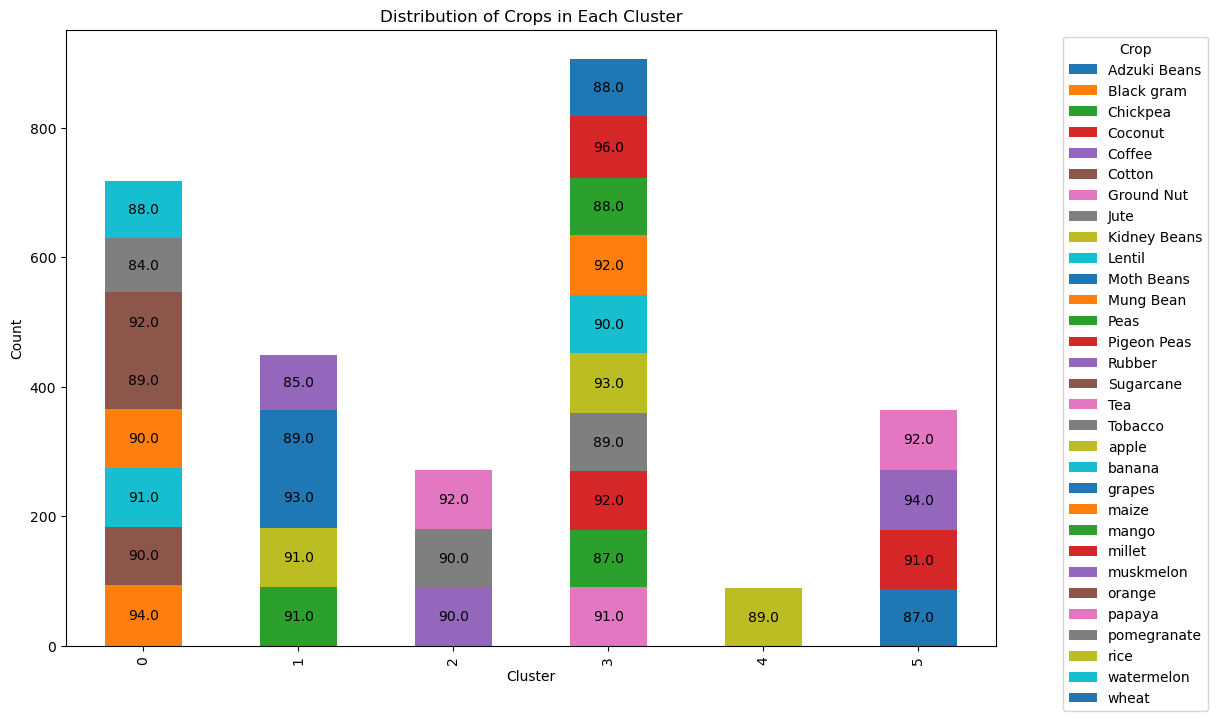

In [56]:
# 统计每个簇中各类 crop 的数量
cluster_crop_counts = data.groupby(['Cluster', 'Crop']).size().unstack(fill_value=0)

# 绘制堆叠柱状图
ax = cluster_crop_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Distribution of Crops in Each Cluster')
plt.legend(title='Crop', loc='upper center', bbox_to_anchor=(1.15, 1))

# 添加数据标签
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.annotate(height, (x + width/2, y + height/2), ha='center', va='center')

plt.show()

Visualize the cluster with the main 

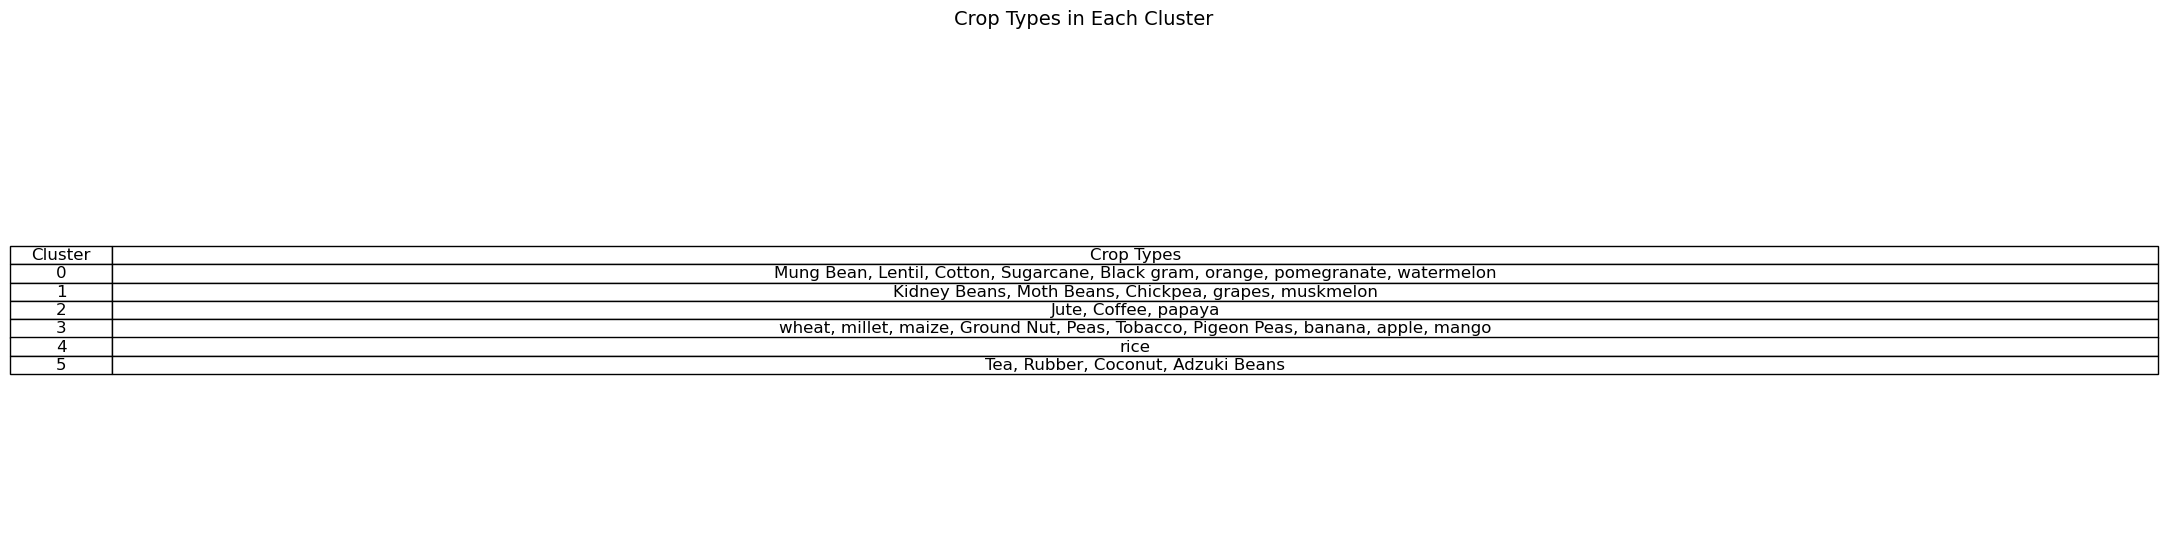

In [72]:
# 统计每个簇中包含的唯一 crop 类型
cluster_crops = data.groupby('Cluster')['Crop'].unique().reset_index()

# 创建表格数据（确保每行的 crop 类型用逗号分隔）
table_data = []
for _, row in cluster_crops.iterrows():
    cluster = row['Cluster']
    crops = ', '.join(row['Crop'])
    table_data.append([cluster, crops])

# 定义列宽（第一列设为较小宽度，第二列根据内容自适应）
col_widths = [0.1, 2]  # 第一列宽度 0.8，第二列宽度 3.0（可根据需求调整）

# 绘制表格
fig, ax = plt.subplots(figsize=(12, 6))  # 适当增大图宽，避免第二列内容换行
ax.axis('tight')
ax.axis('off')

# 添加表格，设置列宽和居中对齐
table = ax.table(
    cellText=table_data,
    colLabels=['Cluster', 'Crop Types'],
    colWidths=col_widths,  # 关键：手动设置列宽
    cellLoc='center',
    loc='center'
)

# 调整字体大小和表格缩放
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.1, 1.1)  # 轻微缩放，避免单元格边框过窄

plt.title('Crop Types in Each Cluster', y=1.1, fontsize=14)
plt.show()